In [17]:
# ─────────────────────────────────────────────
# 환경 준비 — 라이브러리 불러오기 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")   # 학습 중 경고 메시지를 잠시 숨깁니다.

# 재현성: 같은 난수를 항상 같게 만들어 결과가 매번 동일하도록 고정합니다.
np.random.seed(42)

# 한글 폰트 설정 (그래프 안 글자가 깨지지 않도록 운영체제별로 분기)
system = platform.system()
if system == "Darwin":          # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":       # Windows
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                            # Linux 등
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False   # 마이너스 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료! 라이브러리 버전을 확인합니다.")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)

준비 완료! 라이브러리 버전을 확인합니다.
numpy : 2.4.6
pandas: 3.0.3


In [18]:
# 웹 서버 접속 로그 생성 (가상) — 한 줄이 통째로 문자열
np.random.seed(7)
n_logs = 1500
ips = [f"203.0.113.{k}" for k in range(1, 60)] + [f"198.51.100.{k}" for k in range(1, 60)]
paths = ["/", "/products", "/products/123", "/products/456", "/cart",
         "/checkout", "/login", "/search", "/api/orders"]
methods = ["GET", "GET", "GET", "POST"]
statuses = [200, 200, 200, 200, 200, 404, 500, 301]

# 시각: 7일치, 초 단위로 무작위 발생 후 정렬
log_times = pd.to_datetime("2025-03-01") + pd.to_timedelta(
    np.sort(np.random.randint(0, 7 * 24 * 3600, n_logs)), unit="s")

lines = []
for i in range(n_logs):
    ip = np.random.choice(ips)
    ts_str = log_times[i].strftime("%d/%b/%Y:%H:%M:%S")   # 12/Jan/2025:10:15:32
    m = np.random.choice(methods)
    p = np.random.choice(paths)
    st = np.random.choice(statuses)
    sz = np.random.randint(200, 5000)
    lines.append(f'{ip} - - [{ts_str}] "{m} {p} HTTP/1.1" {st} {sz}')

web_logs = pd.DataFrame({"raw": lines})
print("웹 로그 생성 완료:", web_logs.shape)
print("\n[원본 로그 한 줄은 이렇게 생겼습니다]")
for line in web_logs["raw"].head(3):
    print(line)

웹 로그 생성 완료: (1500, 1)

[원본 로그 한 줄은 이렇게 생겼습니다]
203.0.113.39 - - [01/Mar/2025:00:01:14] "GET / HTTP/1.1" 200 2371
198.51.100.21 - - [01/Mar/2025:00:02:24] "GET / HTTP/1.1" 301 284
198.51.100.17 - - [01/Mar/2025:00:02:28] "GET /search HTTP/1.1" 200 1448


In [19]:
# 시나리오 1 — 정규식으로 6개 필드를 한 번에 추출
pattern = (
    r"(?P<ip>\d+\.\d+\.\d+\.\d+)"        # IP: 숫자.숫자.숫자.숫자 r"(?P<ip>/d+\.\d+\.\d+\.\d+)"")
    r" - - \["                            # 고정 구분 부분 r(" - - \[")
    r"(?P<ts>[^\]]+)"                     # 시각: ] 가 아닌 글자들 r"(?P<ts>[A-Za-z0-9:/]+)") 가능은 하지만 덜 안전함
    r"\] \""                              # ] 와 따옴표
    r"(?P<method>\w+) "                   # 방식: GET/POST
    r"(?P<path>\S+)"                      # 경로: 공백 아닌 글자들 \S는 공백 아닌 글자들, \s는 공백 글자들
    r"[^\"]*\" "                          # HTTP/1.1 부분 건너뛰기
    r"(?P<status>\d+) "                   # 상태 코드
    r"(?P<size>\d+)"                      # 응답 크기
)
logs = web_logs["raw"].str.extract(pattern) #extract으로 6개 칼럼 추출
print("추출된 표:", logs.shape)
print(logs.head())
print("\n추출 실패(어느 한 칸이라도 NaN) 행 수:", logs.isna().any(axis=1).sum())

추출된 표: (1500, 6)
              ip                    ts method       path status  size
0   203.0.113.39  01/Mar/2025:00:01:14    GET          /    200  2371
1  198.51.100.21  01/Mar/2025:00:02:24    GET          /    301   284
2  198.51.100.17  01/Mar/2025:00:02:28    GET    /search    200  1448
3   203.0.113.35  01/Mar/2025:00:03:56    GET      /cart    404  3921
4   203.0.113.47  01/Mar/2025:00:14:29    GET  /products    500  2580

추출 실패(어느 한 칸이라도 NaN) 행 수: 0


In [20]:
# 시나리오 2 — 타입 정리(날짜·숫자) + dt 부품
logs["ts"] = pd.to_datetime(logs["ts"], format="%d/%b/%Y:%H:%M:%S", errors="coerce")
logs["status"] = logs["status"].astype(int)
logs["size"] = logs["size"].astype(int)

# dt 부품: 시각(hour)과 요일
logs["hour"] = logs["ts"].dt.hour
logs["dow_name"] = logs["ts"].dt.day_name()

print("정리 후 자료형:")
print(logs.dtypes)
print()
print(logs[["ip", "ts", "method", "path", "status", "hour", "dow_name"]].head())

정리 후 자료형:
ip                     str
ts          datetime64[us]
method                 str
path                   str
status               int64
size                 int64
hour                 int32
dow_name               str
dtype: object

              ip                  ts method       path  status  hour  dow_name
0   203.0.113.39 2025-03-01 00:01:14    GET          /     200     0  Saturday
1  198.51.100.21 2025-03-01 00:02:24    GET          /     301     0  Saturday
2  198.51.100.17 2025-03-01 00:02:28    GET    /search     200     0  Saturday
3   203.0.113.35 2025-03-01 00:03:56    GET      /cart     404     0  Saturday
4   203.0.113.47 2025-03-01 00:14:29    GET  /products     500     0  Saturday


In [21]:
# 시나리오 2 — 상태 코드·인기 경로 빠르게 집계
print("[상태 코드 분포]")
print(logs["status"].value_counts())
print(len(logs["status"]))   

error_rate = (logs["status"] >= 400).mean() * 100   # 4xx·5xx 비율
print(f"\n오류 응답(4xx·5xx) 비율: {error_rate:.1f}%")

print("\n[요청이 많은 경로 TOP 5]")
print(logs["path"].value_counts().head())

[상태 코드 분포]
status
200    964
301    188
404    178
500    170
Name: count, dtype: int64
1500

오류 응답(4xx·5xx) 비율: 23.2%

[요청이 많은 경로 TOP 5]
path
/                184
/search          175
/cart            173
/products/456    171
/products        168
Name: count, dtype: int64


In [32]:
# 경로별 404 / 500 에러 발생 빈도
error_logs = logs[logs["status"].isin([404, 500])]

path_error_counts = error_logs.groupby(["path", "status"]).size().unstack(fill_value=0)
path_error_counts["total_errors"] = path_error_counts.sum(axis=1)
path_error_counts = path_error_counts.sort_values("total_errors", ascending=False)

# 경로별 전체 요청 수 대비 에러율도 같이 보기
path_total = logs.groupby("path").size()
path_error_counts["total_requests"] = path_total
path_error_counts["error_rate(%)"] = (
    path_error_counts["total_errors"] / path_error_counts["total_requests"] * 100
).round(1)

print("\n[경로별 에러율 포함]")
print(path_error_counts.sort_values("error_rate(%)", ascending=False))


[경로별 에러율 포함]
status         404  500  total_errors  total_requests  error_rate(%)
path                                                                
/checkout       28   17            45             161           28.0
/products/456   24   19            43             171           25.1
/cart           17   26            43             173           24.9
/               20   24            44             184           23.9
/api/orders     22   18            40             168           23.8
/login          21   14            35             152           23.0
/products       17   21            38             168           22.6
/products/123   11   17            28             148           18.9
/search         18   14            32             175           18.3


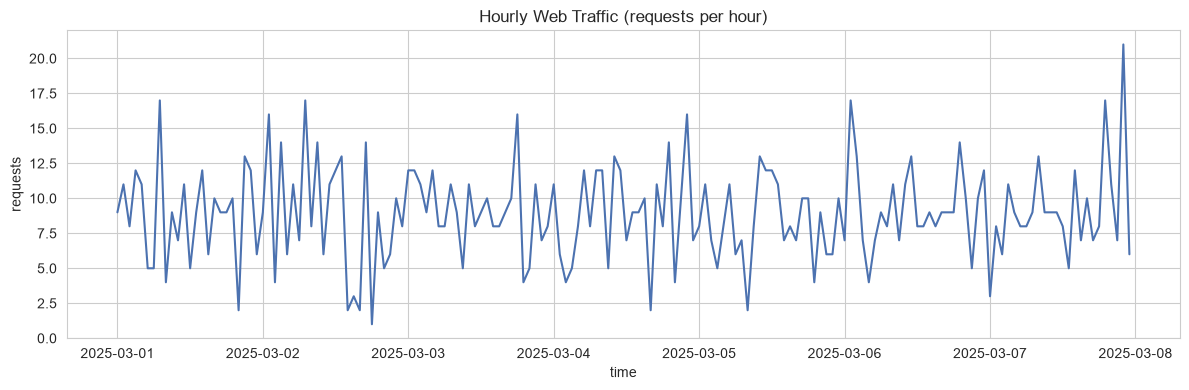

가장 트래픽이 많았던 시간대 TOP 3:
ts
2025-03-07 22:00:00    21
2025-03-01 07:00:00    17
2025-03-06 01:00:00    17
Name: ip, dtype: int64


In [33]:
# 시나리오 3 — 시간대별 트래픽 (resample 'h')
log_ts = logs.dropna(subset=["ts"]).set_index("ts").sort_index()
hourly_traffic = log_ts["ip"].resample("h").count()    # 시간당 요청 수

plt.figure(figsize=(12, 4))
plt.plot(hourly_traffic.index, hourly_traffic.values, color="#4C72B0")
plt.title("Hourly Web Traffic (requests per hour)")
plt.xlabel("time"); plt.ylabel("requests")
plt.tight_layout(); plt.show()

print("가장 트래픽이 많았던 시간대 TOP 3:")
print(hourly_traffic.sort_values(ascending=False).head(3))

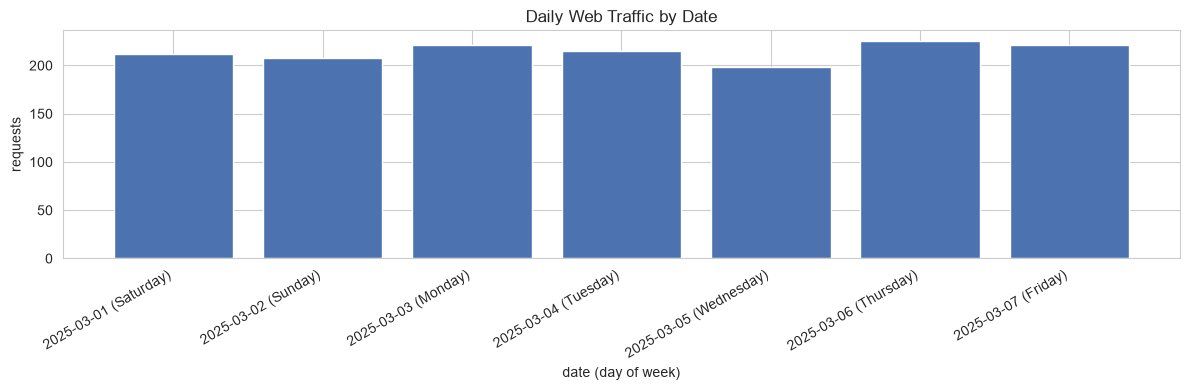

날짜별 트래픽:
2025-03-01 (Saturday): 212건
2025-03-02 (Sunday): 208건
2025-03-03 (Monday): 221건
2025-03-04 (Tuesday): 215건
2025-03-05 (Wednesday): 198건
2025-03-06 (Thursday): 225건
2025-03-07 (Friday): 221건

트래픽이 가장 많았던 날: 2025-03-06 (Thursday) — 225건
트래픽이 가장 적었던 날: 2025-03-05 (Wednesday) — 198건


In [34]:
# 시나리오 4 — 날짜별 하루 트래픽                       #시나리오3에서 진행한 시간대별 트래픽은 요일별로 확인하기 용이하지 않아 날짜별로 그룹지어 진행
logs_valid = logs.dropna(subset=["ts"]).copy()
logs_valid["date"] = logs_valid["ts"].dt.date

daily_traffic = logs_valid.groupby("date").size().sort_index()

# x축 라벨: "2025-03-01 (Saturday)" 형태로 만들기
date_labels = [
    f"{d.strftime('%Y-%m-%d')} ({d.strftime('%A')})"
    for d in daily_traffic.index
]

plt.figure(figsize=(12, 4))
plt.bar(date_labels, daily_traffic.values, color="#4C72B0")
plt.title("Daily Web Traffic by Date")
plt.xlabel("date (day of week)"); plt.ylabel("requests")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.show()

print("날짜별 트래픽:")
for label, cnt in zip(date_labels, daily_traffic.values):
    print(f"{label}: {cnt}건")

max_idx = daily_traffic.idxmax()
min_idx = daily_traffic.idxmin()

max_label = f"{max_idx.strftime('%Y-%m-%d')} ({max_idx.strftime('%A')})"
min_label = f"{min_idx.strftime('%Y-%m-%d')} ({min_idx.strftime('%A')})"

print(f"\n트래픽이 가장 많았던 날: {max_label} — {daily_traffic.max()}건")
print(f"트래픽이 가장 적었던 날: {min_label} — {daily_traffic.min()}건")

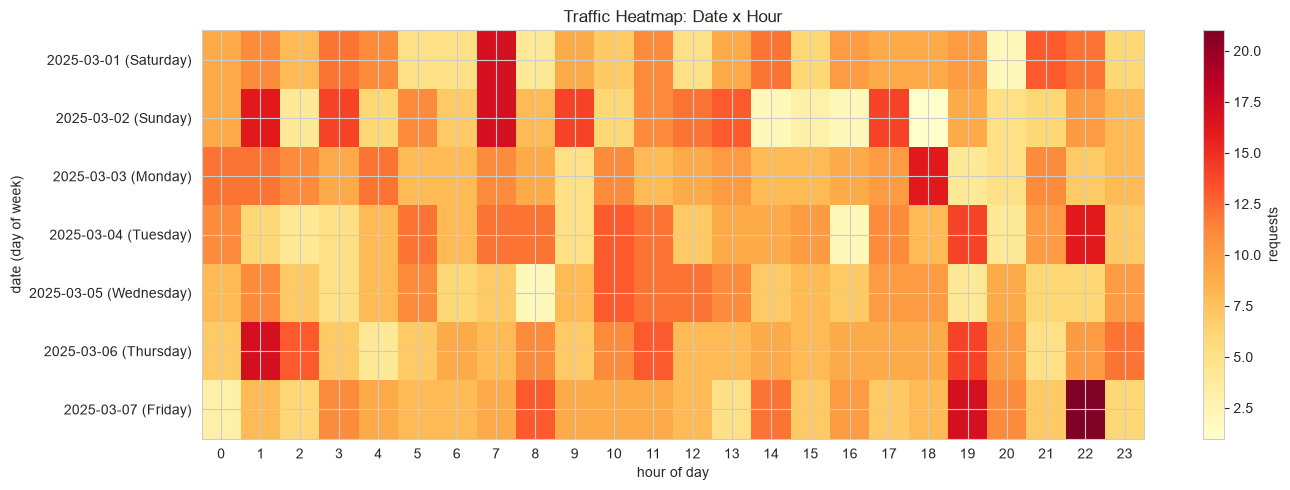

[날짜별 최고 트래픽 시간대]
2025-03-01 (Saturday): 7시 (17건)
2025-03-02 (Sunday): 7시 (17건)
2025-03-03 (Monday): 18시 (16건)
2025-03-04 (Tuesday): 22시 (16건)
2025-03-05 (Wednesday): 10시 (13건)
2025-03-06 (Thursday): 1시 (17건)
2025-03-07 (Friday): 22시 (21건)


In [35]:
# 시나리오 5 — 날짜 x 시간대 트래픽 히트맵          #날짜별로 어느 시간대에 가장 많은 트래픽이 발생했는지 확인.
                                                 #한번에 확인하기 편하게 산점도로 분포도 확인.
                                                 #점검일정, 업로드 등 사이트 운영에 참고가능
logs_valid = logs.dropna(subset=["ts"]).copy()
logs_valid["date"] = logs_valid["ts"].dt.date
date_order = sorted(logs_valid["date"].unique())

pivot = logs_valid.pivot_table(
    index="date", columns="hour", values="ip", aggfunc="count", fill_value=0
).reindex(date_order)

# y축 라벨: "2025-03-01 (Saturday)" 형태
date_labels = [f"{d.strftime('%Y-%m-%d')} ({d.strftime('%A')})" for d in pivot.index]

plt.figure(figsize=(14, 5))
plt.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
plt.colorbar(label="requests")
plt.yticks(range(len(pivot.index)), date_labels)
plt.xticks(range(0, 24), range(0, 24))
plt.xlabel("hour of day"); plt.ylabel("date (day of week)")
plt.title("Traffic Heatmap: Date x Hour")
plt.tight_layout(); plt.show()

# 날짜별로 가장 트래픽 많은 시간대 찾기
print("[날짜별 최고 트래픽 시간대]")
for label, d in zip(date_labels, pivot.index):
    peak_hour = pivot.loc[d].idxmax()
    peak_count = pivot.loc[d].max()
    print(f"{label}: {peak_hour}시 ({peak_count}건)")

In [36]:
# IP별 요청 수 + 오류율 집계
ip_stats = logs.groupby("ip").agg(
    total_requests=("status", "count"),
    error_count=("status", lambda x: (x >= 400).sum())
)
ip_stats["error_rate"] = (ip_stats["error_count"] / ip_stats["total_requests"] * 100).round(1)

# 요청 수 TOP 10 IP
print("[요청이 가장 많은 IP TOP 10]")
print(ip_stats.sort_values("total_requests", ascending=False).head(10))

# 오류율이 유독 높은 IP (요청 5건 이상인 것 중)
print("\n[오류율이 높은 IP (요청 5건 이상)]")
suspicious = ip_stats[ip_stats["total_requests"] >= 5].sort_values("error_rate", ascending=False)
print(suspicious.head(10))

[요청이 가장 많은 IP TOP 10]
               total_requests  error_count  error_rate
ip                                                    
198.51.100.41              24            4        16.7
203.0.113.58               21           10        47.6
203.0.113.18               19            6        31.6
203.0.113.27               19            2        10.5
198.51.100.52              19            2        10.5
198.51.100.24              18            5        27.8
203.0.113.16               18            0         0.0
198.51.100.28              18            3        16.7
203.0.113.56               18            6        33.3
203.0.113.35               18            3        16.7

[오류율이 높은 IP (요청 5건 이상)]
               total_requests  error_count  error_rate
ip                                                    
203.0.113.4                 7            5        71.4
198.51.100.22              10            5        50.0
203.0.113.30               10            5        50.0
203.0.113.36      